# 26a. 전역적 해석 (Global Interpretation)

SHAP Summary Plot 등을 통해 전체 데이터 관점에서 어떤 피처가 고장 예측에 주요하게 기여하는지 분석합니다.

## 0. 환경 준비

In [ ]:
import sys, os, json, joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

sys.path.insert(0, os.path.abspath(".."))

%load_ext autoreload
%autoreload 2

import config.interp_config as cfg
import config.train_config as tcfg
import config.final_eval_config as fe_cfg
from src.eval_core import prepare_disk_level_data, get_detailed_disk_records

warnings.filterwarnings("ignore")

# 한글 폰트 설정
for _font in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
    if any(_font.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False

print("✅ 환경 준비 완료")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ 환경 준비 완료


## 1. 모델 및 데이터 로드

In [ ]:
from pathlib import Path

SAVE_DIR = Path(tcfg.MODEL_SAVE_DIR)

# ── 피처 목록 로드 ─────────────────────────────────────────
with open(SAVE_DIR / "feature_cols.json", encoding="utf-8") as f:
    FEATURE_COLS = json.load(f)

# ── 앙상블 모델 로드 ───────────────────────────────────────
models = [joblib.load(p) for p in sorted(SAVE_DIR.glob("subset_*.pkl"))]

# ── 최적 임계값 로드 (final_eval_config 에서 가져옴) ─────────
# 수동 오버라이드 (config에 설정된 경우 우선 적용)
BEST_T = getattr(fe_cfg, "MANUAL_BEST_T", None)
BEST_N = getattr(fe_cfg, "MANUAL_BEST_N", None)
if BEST_T is None or BEST_N is None:
    with open(SAVE_DIR / "best_threshold.json", encoding="utf-8") as f:
        th_data = json.load(f)
        if BEST_T is None: BEST_T = th_data["threshold"]
        if BEST_N is None: BEST_N = th_data["min_alarms"]
ALARM_WINDOW = getattr(fe_cfg, "ALARM_WINDOW", 14)

# ── 테스트 데이터 로드 (고장 당일 포함본) ───────────────────
# interp_config 대신 최신 데이터가 반영된 final_eval_config의 경로 사용
test_path = Path(fe_cfg.TEST_PATH)
df_test = pd.read_parquet(test_path)
df_test[cfg.DATE_COL] = pd.to_datetime(df_test[cfg.DATE_COL])
df_test['base_serial'] = df_test[cfg.SERIAL_COL].str.replace(r'_\d+$', '', regex=True)

# ── 앙상블 예측 (캐시 활용) ─────────────────────────────────
cache_filename = f"{test_path.stem}_probs.npy"
cache_path = Path(getattr(tcfg, "PREDICTIONS_DIR", SAVE_DIR)) / cache_filename

if os.path.exists(cache_path):
    print(f"♻️ 캐시 로드 중: {cache_filename}")
    y_prob = np.load(cache_path)
    if len(y_prob) != len(df_test):
        print("⚠️ 데이터 크기 불일치. 재예측 수행...")
        y_prob = np.mean([m.predict_proba(df_test[FEATURE_COLS])[:, 1] for m in models], axis=0)
        np.save(cache_path, y_prob)
else:
    print(f"🔄 앙상블 추론 중... (모델 {len(models)}개 × 데이터 {len(df_test):,}행)")
    y_prob = np.mean([m.predict_proba(df_test[FEATURE_COLS])[:, 1] for m in models], axis=0)
    np.save(cache_path, y_prob)

df_test["_prob"]  = y_prob

print(f"✅ 로드 완료: 피처 {len(FEATURE_COLS)}개 | 운영점 T={BEST_T:.4f}, n={BEST_N} (W={ALARM_WINDOW})")
print(f"   테스트 데이터: {len(df_test):,}행 | 고장행: {df_test[cfg.TARGET_COL].sum():,}")

# ── 실제 디스크 단위 알람 이력 추출 (n회 연속 조건 반영) ──────
disks_data, n_fail, n_norm = prepare_disk_level_data(df_test, y_prob)
df_best_disk = get_detailed_disk_records(disks_data, BEST_T, BEST_N, window_size=ALARM_WINDOW)
# _alarm 컬럼을 단순 확률(1회)가 아니라 n회 조건 만족 여부로 생성하기 위해 
# 원래 df_test 에 매핑하기는 복잡하므로 df_best_disk 정보를 활용합니다.


♻️ 캐시 로드 중: test_with_failure_date_probs.npy
✅ 로드 완료: 피처 27개 | 운영점 T=0.9261, n=2 (W=14)
   테스트 데이터: 15,696,223행 | 고장행: 12,256


KeyboardInterrupt: 

---
## §9.1 전역적 해석 (Global Interpretability)

SHAP Summary Plot을 통해 전체 테스트 데이터에서 어떤 피처가 고장 예측에 얼마나, 어떤 방향으로 기여하는지 분석합니다.

- 앙상블 모델 전체의 평균 SHAP 값을 사용
- **x축:** 개별 예측에 대한 SHAP 값 (양수 = 고장 확률 증가에 기여)
- **색상:** 해당 피처의 원본 값 수준 (붉을수록 높은 값)

In [ ]:
import shap

# SHAP 계산용 5:5 균형 추출 (고장 패턴을 전역 해석에서 뚜렷하게 보기 위함)
sample_size = min(cfg.SHAP_SAMPLE_SIZE, len(df_test))
target_fail_count = sample_size // 2

# 1. 고장/정상 인덱스 분리
fail_indices = df_test[df_test[cfg.TARGET_COL] == 1].index
norm_indices = df_test[df_test[cfg.TARGET_COL] == 0].index

# 2. 고장 데이터 샘플링 (전체 샘플의 절반을 목표로 하되, 모자라면 전수 사용)
n_fail_sample = min(len(fail_indices), target_fail_count)
# 나머지를 정상 데이터로 채움
n_norm_sample = sample_size - n_fail_sample

fail_sample = df_test.loc[fail_indices].sample(n_fail_sample, random_state=cfg.SHAP_SEED)
norm_sample = df_test.loc[norm_indices].sample(n_norm_sample, random_state=cfg.SHAP_SEED)

# 3. 데이터셋 결합 및 셔플 (순서가 뭉치지 않게)
df_sample = pd.concat([fail_sample, norm_sample]).sample(frac=1, random_state=cfg.SHAP_SEED).reset_index(drop=True)

X_sample = df_sample[FEATURE_COLS]
y_sample = df_sample[cfg.TARGET_COL]

print(f"SHAP 계산 준비... (샘플={sample_size:,}, 모델={len(models)}개)")
print(f"  → 균형 튜닝 추출 완료: 고장 {n_fail_sample:,}개 / 정상 {n_norm_sample:,}개")

shap_cache_path = SAVE_DIR / f"shap_cache_seed{cfg.SHAP_SEED}_size{sample_size}.npy"

if os.path.exists(shap_cache_path):
    print(f"♻️ 전역 SHAP 캐시 로드 중: {shap_cache_path.name}")
    mean_shap = np.load(shap_cache_path)
    print(f"✅ SHAP 캐시 로드 완료!")
else:
    print("  ※ 모델 수 × 샘플 수에 비례하여 수 분 소요될 수 있습니다.")
    sv_list = []
    for i, model in enumerate(models):
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_sample)
        if isinstance(sv, list):
            sv = sv[1]  # 이진 분류: 양성 클래스(고장) SHAP
        sv_list.append(sv)
        print(f"  모델 {i+1}/{len(models)} 완료", end="\r")
    
    mean_shap = np.mean(sv_list, axis=0)
    np.save(shap_cache_path, mean_shap)
    try:
        import subprocess
        subprocess.run(['git', 'add', str(shap_cache_path)], check=True)
        print(f'\n✅  SHAP 계산 및 캐시 저장(Git Add 자동화) 완료!')
    except Exception as e:
        print(f'\n✅  SHAP 계산 및 캐시 저장 완료! (Git 자동 등록 실패: {e})')


SHAP 계산 준비... (샘플=6,000, 모델=10개)
  → 균형 튜닝 추출 완료: 고장 3,000개 / 정상 3,000개
♻️ 전역 SHAP 캐시 로드 중: shap_cache_seed42_size6000.npy
✅ SHAP 캐시 로드 완료!


[§9.1] SHAP Summary Plot (전역 해석)


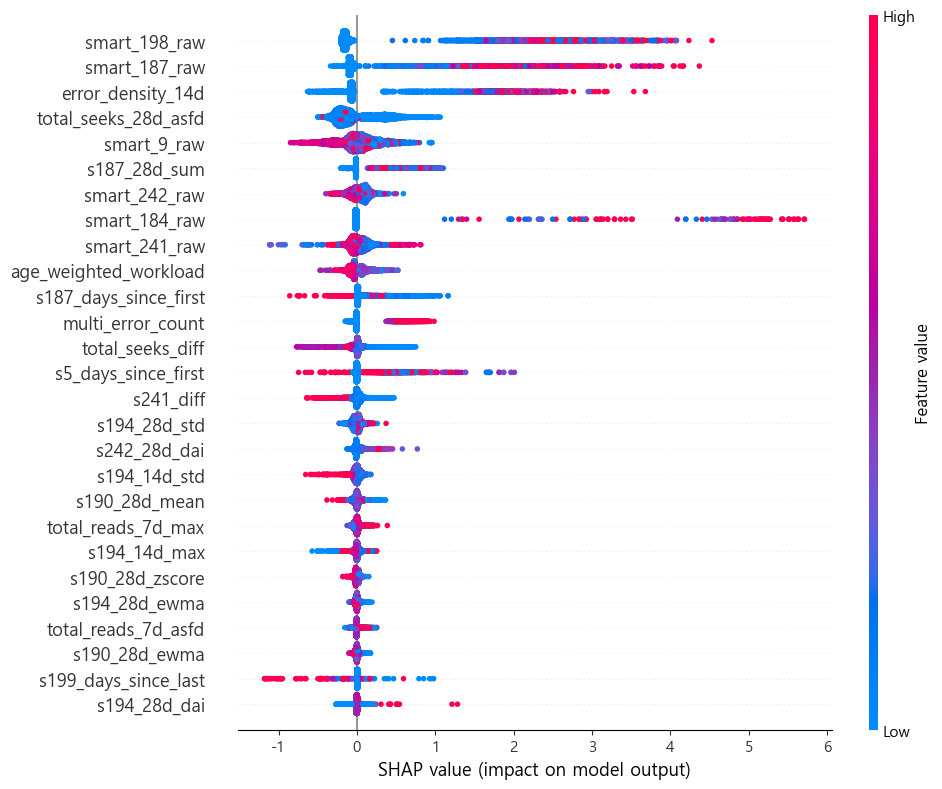

In [ ]:
# §9.1 Summary Plot (Beeswarm)
print("[§9.1] SHAP Summary Plot (전역 해석)")
shap.summary_plot(
    mean_shap,
    X_sample,
    feature_names=FEATURE_COLS,
    max_display=cfg.SHAP_MAX_DISPLAY,
    show=True,
    plot_size=(10, 8),
)

[§9.1] SHAP Bar Plot (Mean |SHAP| 기준 피처 중요도)


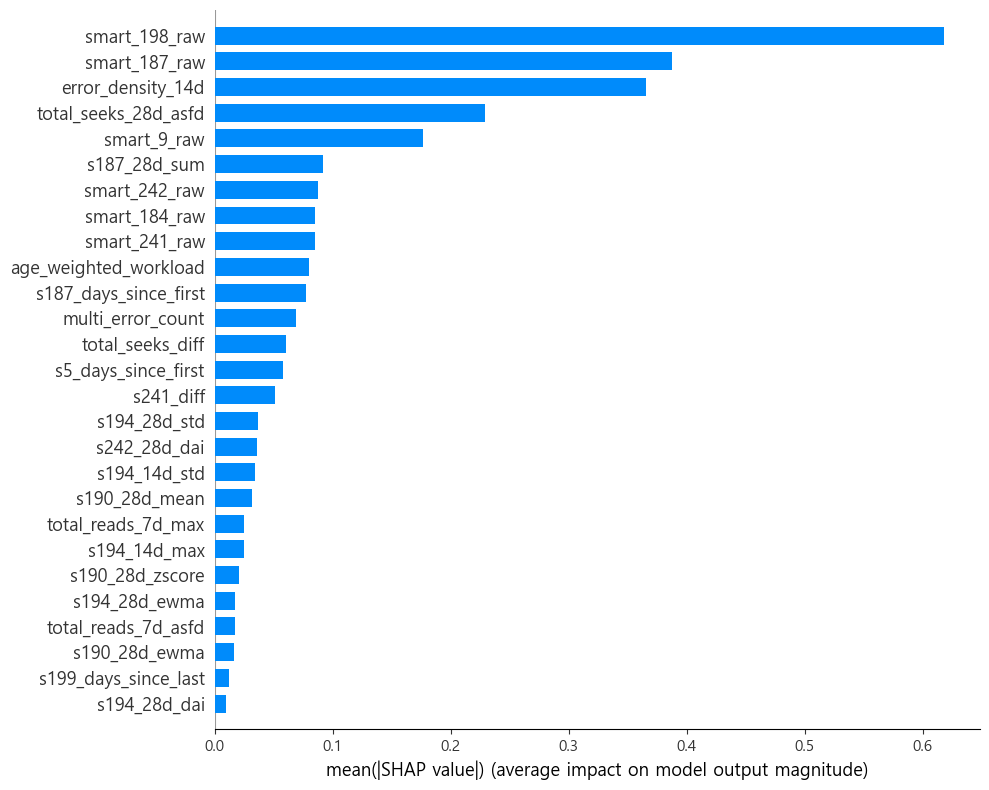


📊 피처 중요도 순위 (Mean |SHAP|):
|    | feature               |   mean_abs_shap |
|---:|:----------------------|----------------:|
|  1 | smart_198_raw         |      0.6176     |
|  2 | smart_187_raw         |      0.387535   |
|  3 | error_density_14d     |      0.36514    |
|  4 | total_seeks_28d_asfd  |      0.228769   |
|  5 | smart_9_raw           |      0.176668   |
|  6 | s187_28d_sum          |      0.0915711  |
|  7 | smart_242_raw         |      0.0875417  |
|  8 | smart_184_raw         |      0.0854291  |
|  9 | smart_241_raw         |      0.0849411  |
| 10 | age_weighted_workload |      0.0799305  |
| 11 | s187_days_since_first |      0.0776488  |
| 12 | multi_error_count     |      0.0692159  |
| 13 | total_seeks_diff      |      0.0605762  |
| 14 | s5_days_since_first   |      0.0577827  |
| 15 | s241_diff             |      0.0514774  |
| 16 | s194_28d_std          |      0.0371828  |
| 17 | s242_28d_dai          |      0.0356629  |
| 18 | s194_14d_std          |      0.034

In [ ]:
# §9.1 Bar Plot — 절댓값 평균 기준 피처 중요도
print("[§9.1] SHAP Bar Plot (Mean |SHAP| 기준 피처 중요도)")
shap.summary_plot(
    mean_shap,
    X_sample,
    feature_names=FEATURE_COLS,
    max_display=cfg.SHAP_MAX_DISPLAY,
    plot_type="bar",
    show=True,
    plot_size=(10, 8),
)

# 중요도 순위 테이블 출력
mean_abs_shap = np.abs(mean_shap).mean(axis=0)
shap_rank_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "mean_abs_shap": mean_abs_shap})
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
shap_rank_df.index += 1
print("\n📊 피처 중요도 순위 (Mean |SHAP|):")
print(shap_rank_df.to_markdown())